In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("zomato.csv")
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [3]:
df.shape        # how many rows and columns
df.columns      # column names
df.isnull().sum() # missing values

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [4]:
df = df.dropna(subset=['rate', 'location', 'cuisines'])
df['rate'] = df['rate'].astype(str).str.replace('/5', '').str.strip()
df = df[df['rate'] != 'NEW']
df = df[df['rate'] != '-']
df['rate'] = df['rate'].astype(float)
df.shape

(41654, 17)

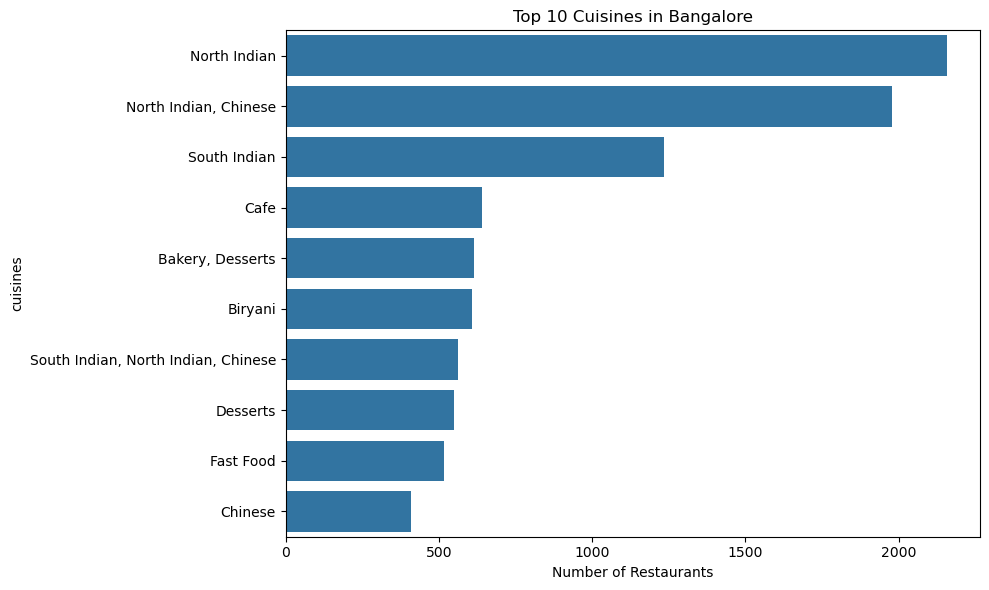

In [5]:
top_cuisines = df['cuisines'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_cuisines.values, y=top_cuisines.index)
plt.title("Top 10 Cuisines in Bangalore")
plt.xlabel("Number of Restaurants")
plt.tight_layout()
plt.show()

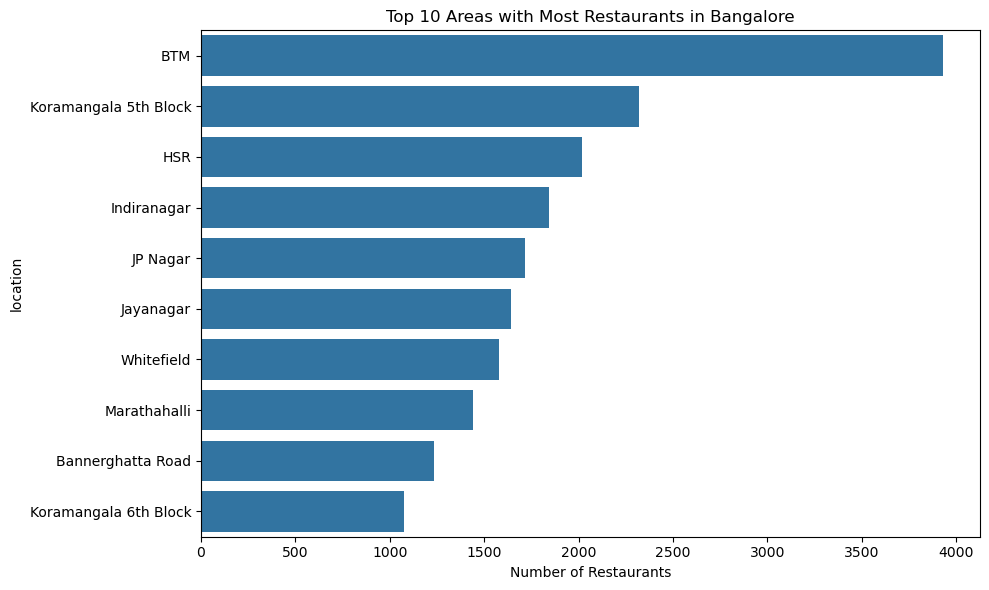

In [6]:
top_areas = df['location'].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_areas.values, y=top_areas.index)
plt.title("Top 10 Areas with Most Restaurants in Bangalore")
plt.xlabel("Number of Restaurants")
plt.tight_layout()
plt.show()

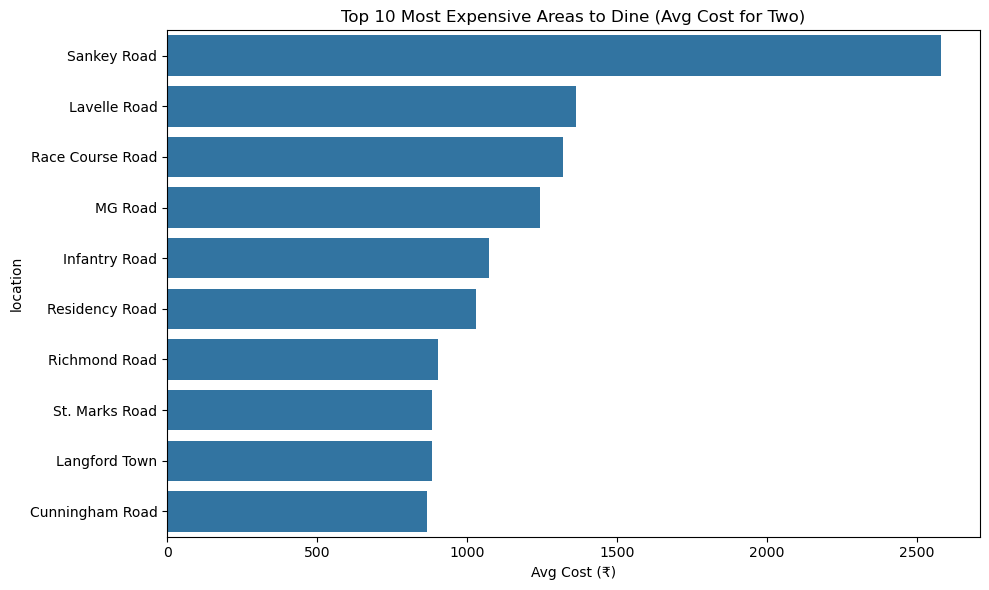

In [7]:
df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'].astype(str).str.replace(',', ''),
    errors='coerce'
)
avg_cost = df.groupby('location')['approx_cost(for two people)'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_cost.values, y=avg_cost.index)
plt.title("Top 10 Most Expensive Areas to Dine (Avg Cost for Two)")
plt.xlabel("Avg Cost (₹)")
plt.tight_layout()
plt.show()

In [8]:
print("=== KEY FINDINGS ===")
print("1. North Indian is the most popular cuisine in Bangalore (2200+ restaurants)")
print("2. BTM Layout has the highest number of restaurants in the city")
print("3. Sankey Tank is the most expensive area to dine, followed by Lavelle Road")

=== KEY FINDINGS ===
1. North Indian is the most popular cuisine in Bangalore (2200+ restaurants)
2. BTM Layout has the highest number of restaurants in the city
3. Sankey Tank is the most expensive area to dine, followed by Lavelle Road
